# 1. Introduction & Project Overview

**Project:** Image Denoising using a Convolutional Autoencoder on MNIST

**Objective:** Train a convolutional autoencoder that accepts a corrupted (noisy)
handwritten digit image and reconstructs a clean version of it.


## 2. Import Required Libraries

In [1]:
import os
import copy
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Torch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


## 3. Set Random Seed for Reproducibility

In [2]:
RANDOM_SEED = 7

def set_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Random seed fixed at {RANDOM_SEED}")

Random seed fixed at 7


## 4. Configure Device (GPU / CPU)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

Running on: cpu


## 5. Define Hyperparameters


In [4]:
CONFIG = {
    "img_size": 28,
    "bottleneck_channels": 128,
    "batch_size": 128,
    "val_fraction": 0.15,
    "num_epochs": 18,
    "learning_rate": 2e-3,
    "weight_decay": 1e-5,
    "gaussian_noise_std": 0.30,
    "speckle_noise_std": 0.15,
    "l1_loss_weight": 0.2,
    "mse_loss_weight": 0.8,
    "lr_patience": 2,
    "lr_factor": 0.5,
    "checkpoint_path": "conv_dae_mnist_best.pt",
}
for k, v in CONFIG.items():
    print(f"{k:22s}: {v}")

img_size              : 28
bottleneck_channels   : 128
batch_size            : 128
val_fraction          : 0.15
num_epochs            : 18
learning_rate         : 0.002
weight_decay          : 1e-05
gaussian_noise_std    : 0.3
speckle_noise_std     : 0.15
l1_loss_weight        : 0.2
mse_loss_weight       : 0.8
lr_patience           : 2
lr_factor             : 0.5
checkpoint_path       : conv_dae_mnist_best.pt


## 6. Download MNIST Dataset


In [5]:
DATA_ROOT = "./mnist_data"

base_transform = transforms.Compose([
    transforms.ToTensor(),  # scales pixels to [0, 1]
])

train_full_dataset = datasets.MNIST(
    root=DATA_ROOT, train=True, download=True, transform=base_transform
)
test_dataset = datasets.MNIST(
    root=DATA_ROOT, train=False, download=True, transform=base_transform
)

print("Full training set size:", len(train_full_dataset))
print("Test set size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 138MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 56.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 42.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


Full training set size: 60000
Test set size: 10000


## 7. Create Train / Validation / Test Splits

In [6]:
val_size = int(CONFIG["val_fraction"] * len(train_full_dataset))
train_size = len(train_full_dataset) - val_size

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

print(f"Train samples      : {len(train_dataset)}")
print(f"Validation samples : {len(val_dataset)}")
print(f"Test samples       : {len(test_dataset)}")

Train samples      : 51000
Validation samples : 9000
Test samples       : 10000


## 8. Build DataLoaders

In [7]:
train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2
)

print("Number of training batches  :", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches      :", len(test_loader))

Number of training batches  : 398
Number of validation batches: 71
Number of test batches      : 79


## 9. Inspect Dataset Samples

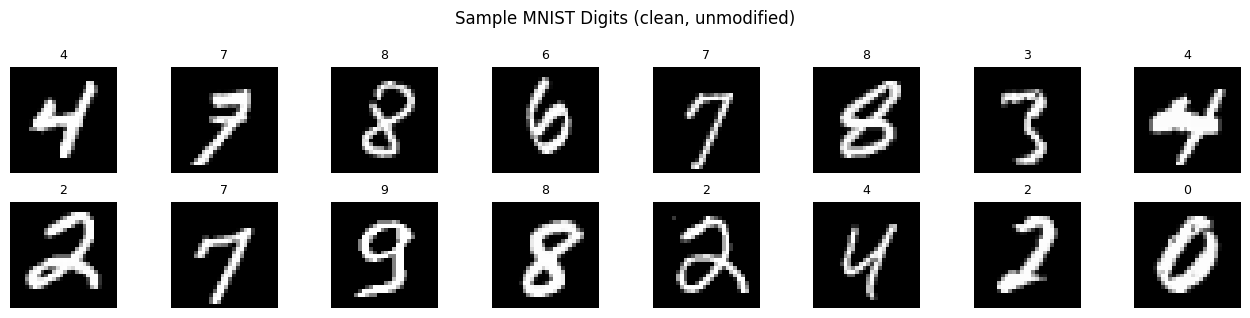

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.2))
sample_imgs, sample_lbls = next(iter(train_loader))
for i in range(16):
    r, c = divmod(i, 8)
    axes[r, c].imshow(sample_imgs[i].squeeze(), cmap="gray")
    axes[r, c].set_title(str(sample_lbls[i].item()), fontsize=9)
    axes[r, c].axis("off")
plt.suptitle("Sample MNIST Digits (clean, unmodified)")
plt.tight_layout()
plt.show()

## 10. Define Noise Injection Function


In [9]:
def corrupt_batch(images: torch.Tensor,
                   gaussian_std: float = CONFIG["gaussian_noise_std"],
                   speckle_std: float = CONFIG["speckle_noise_std"]) -> torch.Tensor:
    """Apply combined additive Gaussian + multiplicative speckle noise."""
    gaussian_component = gaussian_std * torch.randn_like(images)
    speckle_component = images * (speckle_std * torch.randn_like(images))
    corrupted = images + gaussian_component + speckle_component
    return torch.clamp(corrupted, 0.0, 1.0)

## 11. Visualize Clean vs Noisy Images

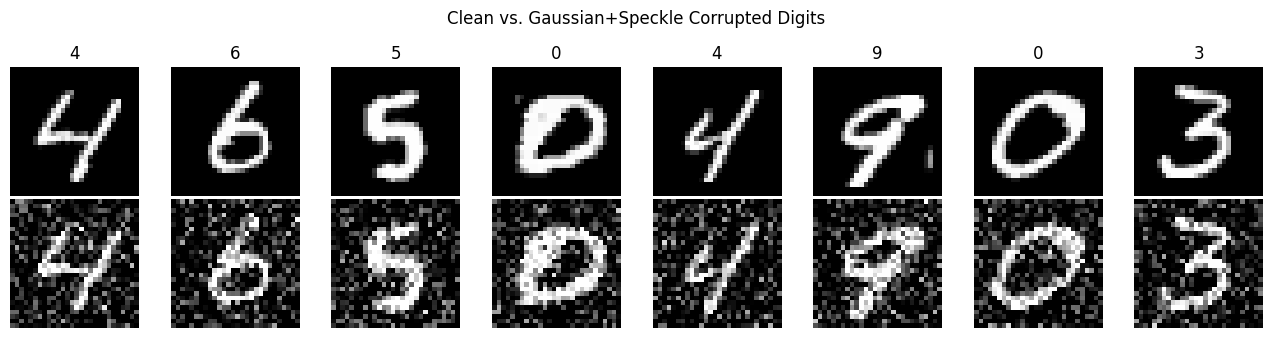

In [10]:
preview_clean, preview_labels = next(iter(train_loader))
preview_clean = preview_clean[:8]
preview_labels = preview_labels[:8]
preview_noisy = corrupt_batch(preview_clean)

fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for i in range(8):
    axes[0, i].imshow(preview_clean[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(str(preview_labels[i].item()))
    axes[0, i].axis("off")
    axes[1, i].imshow(preview_noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=11)
axes[1, 0].set_ylabel("Corrupted", fontsize=11)
plt.suptitle("Clean vs. Gaussian+Speckle Corrupted Digits")
plt.tight_layout()
plt.show()

## 12. Define Convolutional Autoencoder Architecture



In [11]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self, bottleneck_channels: int = CONFIG["bottleneck_channels"]):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(64, bottleneck_channels, kernel_size=3, stride=2, padding=1),  # 7x7 -> 4x4
            nn.BatchNorm2d(bottleneck_channels),
            nn.LeakyReLU(0.1, inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(bottleneck_channels, 64, kernel_size=3, stride=2,
                                padding=1, output_padding=0),  # 4x4 -> 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                                padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2,
                                padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1, inplace=True),

            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


model = ConvDenoisingAutoencoder().to(device)
print(model)

ConvDenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): ConvTranspose2d(64, 32, kernel_s

## 13. Initialize Model, Loss, and Optimizer

In [12]:
def combined_reconstruction_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Weighted mix of MSE and L1 loss (sharper reconstructions than MSE alone)."""
    mse_term = F.mse_loss(pred, target)
    l1_term = F.l1_loss(pred, target)
    return CONFIG["mse_loss_weight"] * mse_term + CONFIG["l1_loss_weight"] * l1_term


optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["lr_factor"], patience=CONFIG["lr_patience"]
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters    : 190,369
Trainable parameters: 190,369


## 14. Define Training Function (one epoch)

In [13]:
def run_training_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    for clean_imgs, _ in loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = corrupt_batch(clean_imgs)

        optimizer.zero_grad()
        reconstructed = model(noisy_imgs)
        loss = combined_reconstruction_loss(reconstructed, clean_imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * clean_imgs.size(0)

    return running_loss / len(loader.dataset)

## 15. Define Validation Function

In [14]:
@torch.no_grad()
def run_validation_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    for clean_imgs, _ in loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = corrupt_batch(clean_imgs)

        reconstructed = model(noisy_imgs)
        loss = combined_reconstruction_loss(reconstructed, clean_imgs)
        running_loss += loss.item() * clean_imgs.size(0)

    return running_loss / len(loader.dataset)

## 16. Train the Autoencoder

In [15]:
history = {"train_loss": [], "val_loss": [], "lr": []}
best_val_loss = float("inf")
best_state_dict = None

for epoch in range(1, CONFIG["num_epochs"] + 1):
    train_loss = run_training_epoch(model, train_loader, optimizer)
    val_loss = run_validation_epoch(model, val_loader)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        torch.save(best_state_dict, CONFIG["checkpoint_path"])
        marker = "  <- new best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']} | "
          f"train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | "
          f"lr={current_lr:.2e}{marker}")

print(f"\nBest validation loss: {best_val_loss:.5f}")
model.load_state_dict(best_state_dict)

Epoch 01/18 | train_loss=0.01749 | val_loss=0.00955 | lr=2.00e-03  <- new best
Epoch 02/18 | train_loss=0.00924 | val_loss=0.00902 | lr=2.00e-03  <- new best
Epoch 03/18 | train_loss=0.00881 | val_loss=0.00863 | lr=2.00e-03  <- new best
Epoch 04/18 | train_loss=0.00861 | val_loss=0.00862 | lr=2.00e-03  <- new best
Epoch 05/18 | train_loss=0.00842 | val_loss=0.00831 | lr=2.00e-03  <- new best
Epoch 06/18 | train_loss=0.00835 | val_loss=0.00832 | lr=2.00e-03
Epoch 07/18 | train_loss=0.00828 | val_loss=0.00818 | lr=2.00e-03  <- new best
Epoch 08/18 | train_loss=0.00818 | val_loss=0.00811 | lr=2.00e-03  <- new best
Epoch 09/18 | train_loss=0.00811 | val_loss=0.00826 | lr=2.00e-03
Epoch 10/18 | train_loss=0.00806 | val_loss=0.00807 | lr=2.00e-03  <- new best
Epoch 11/18 | train_loss=0.00802 | val_loss=0.00789 | lr=2.00e-03  <- new best
Epoch 12/18 | train_loss=0.00798 | val_loss=0.00793 | lr=2.00e-03
Epoch 13/18 | train_loss=0.00793 | val_loss=0.00799 | lr=2.00e-03
Epoch 14/18 | train_loss=

<All keys matched successfully>

## 17. Plot Training and Validation Loss Curves

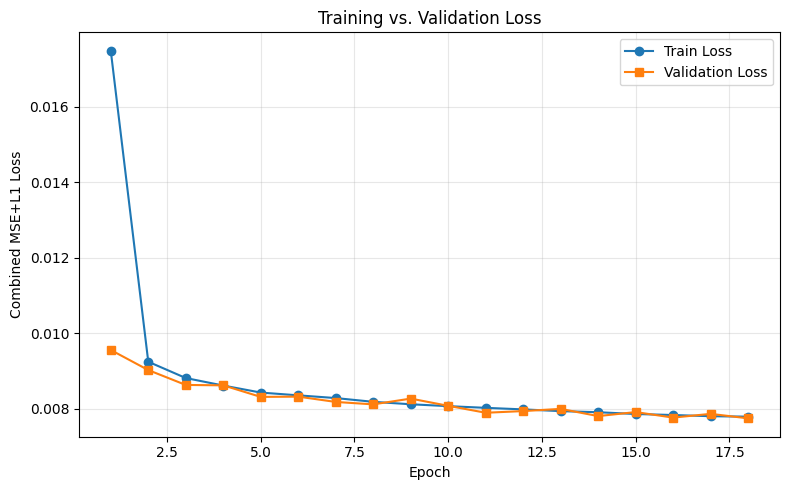

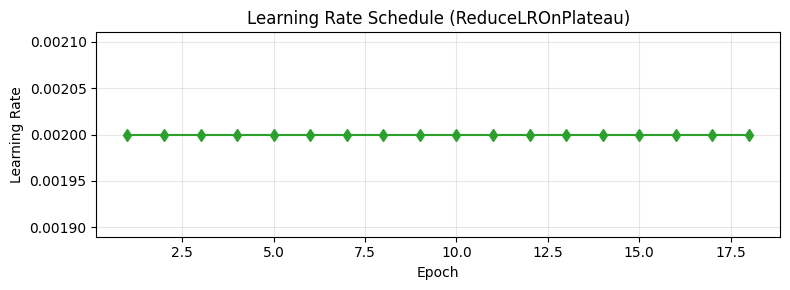

In [16]:
epochs_range = range(1, CONFIG["num_epochs"] + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss", color="tab:blue")
ax1.plot(epochs_range, history["val_loss"], marker="s", label="Validation Loss", color="tab:orange")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Combined MSE+L1 Loss")
ax1.set_title("Training vs. Validation Loss")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(epochs_range, history["lr"], marker="d", color="tab:green")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule (ReduceLROnPlateau)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Define PSNR Metric Function

**PSNR (Peak Signal-to-Noise Ratio)** measures pixel-level reconstruction
quality in decibels — higher values indicate a reconstruction closer to the
original clean image.

In [17]:
def compute_psnr(reconstructed: np.ndarray, reference: np.ndarray, max_pixel_value: float = 1.0) -> float:
    mse = np.mean((reconstructed - reference) ** 2)
    if mse == 0:
        return float("inf")
    return 10.0 * math.log10((max_pixel_value ** 2) / mse)

## 19. Evaluate Model on Test Set (PSNR Scores)

In [18]:
@torch.no_grad()
def evaluate_psnr_on_test_set(model, loader):
    model.eval()
    psnr_baseline_scores = []   # noisy vs. clean
    psnr_denoised_scores = []   # model output vs. clean

    for clean_imgs, _ in loader:
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = corrupt_batch(clean_imgs)
        denoised_imgs = model(noisy_imgs)

        clean_np = clean_imgs.cpu().numpy()
        noisy_np = noisy_imgs.cpu().numpy()
        denoised_np = denoised_imgs.cpu().numpy()

        for i in range(clean_np.shape[0]):
            psnr_baseline_scores.append(compute_psnr(noisy_np[i, 0], clean_np[i, 0]))
            psnr_denoised_scores.append(compute_psnr(denoised_np[i, 0], clean_np[i, 0]))

    return {
        "psnr_noisy_mean": float(np.mean(psnr_baseline_scores)),
        "psnr_denoised_mean": float(np.mean(psnr_denoised_scores)),
        "psnr_improvement_db": float(np.mean(psnr_denoised_scores) - np.mean(psnr_baseline_scores)),
    }


psnr_results = evaluate_psnr_on_test_set(model, test_loader)
print("=== PSNR Evaluation on Full Test Set ===")
print(f"Average PSNR (noisy   vs clean) : {psnr_results['psnr_noisy_mean']:.2f} dB")
print(f"Average PSNR (denoised vs clean): {psnr_results['psnr_denoised_mean']:.2f} dB")
print(f"Improvement                      : +{psnr_results['psnr_improvement_db']:.2f} dB")

=== PSNR Evaluation on Full Test Set ===
Average PSNR (noisy   vs clean) : 13.21 dB
Average PSNR (denoised vs clean): 23.65 dB
Improvement                      : +10.45 dB


## 20. Visualize Original vs Noisy vs Denoised, and Conclusion

Side-by-side comparison of **original -> corrupted -> denoised** digits from
the test set, followed by a short summary of findings.

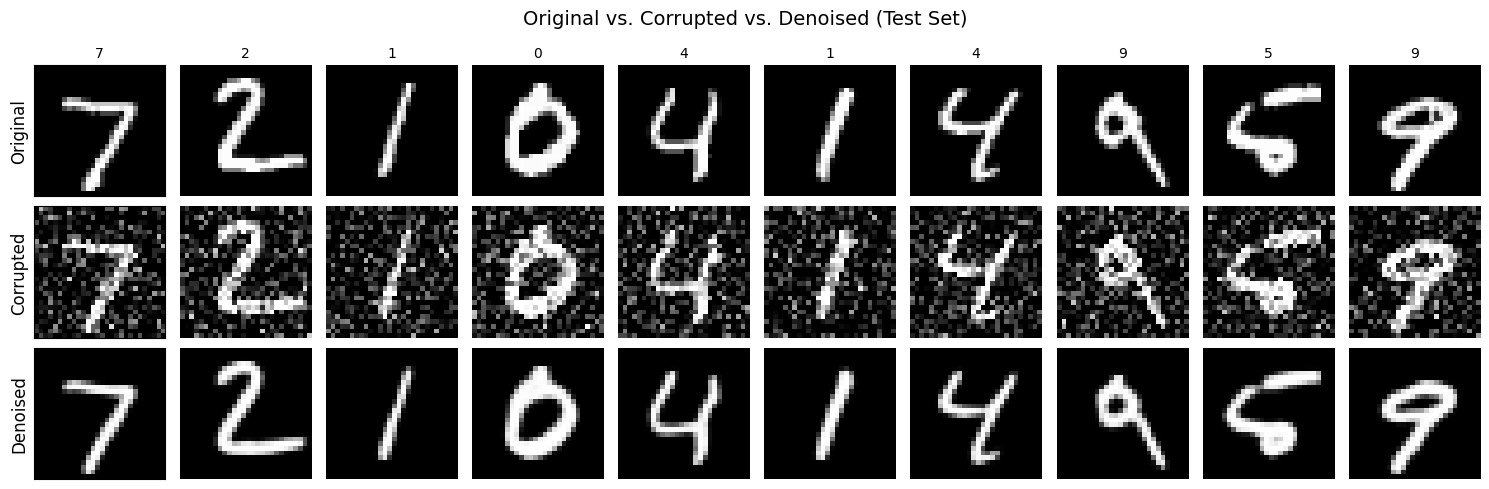

CONCLUSION

This convolutional denoising autoencoder was trained for 18 epochs
on MNIST digits corrupted with combined Gaussian (std=0.3)
and speckle (std=0.15) noise.

Key results:
  - Best validation loss (0.8*MSE + 0.2*L1): 0.00774
  - Mean PSNR of corrupted inputs vs. clean : 13.21 dB
  - Mean PSNR of denoised outputs vs. clean : 23.65 dB
  - Net PSNR improvement from denoising     : +10.45 dB

The visual comparisons above confirm the model recovers digit shape and identity
even under compound noise, though very thin/fine strokes are sometimes softened.

Possible extensions:
  - Add a perceptual/SSIM loss term.
  - Try a variational or U-Net-style skip-connected autoencoder.
  - Sweep noise intensities during training (curriculum-style) for robustness.
  - Benchmark against a plain fully-connected (dense) autoencoder baseline.



In [19]:
@torch.no_grad()
def show_denoising_examples(model, loader, num_examples: int = 10):
    model.eval()
    clean_batch, labels_batch = next(iter(loader))
    clean_batch = clean_batch[:num_examples].to(device)
    labels_batch = labels_batch[:num_examples]

    noisy_batch = corrupt_batch(clean_batch)
    denoised_batch = model(noisy_batch)

    clean_np = clean_batch.cpu().numpy()
    noisy_np = noisy_batch.cpu().numpy()
    denoised_np = denoised_batch.cpu().numpy()
    labels_np = labels_batch.numpy()

    row_titles = ["Original", "Corrupted", "Denoised"]
    rows_data = [clean_np, noisy_np, denoised_np]

    fig, axes = plt.subplots(3, num_examples, figsize=(1.5 * num_examples, 5))
    for r in range(3):
        for c in range(num_examples):
            axes[r, c].imshow(rows_data[r][c, 0], cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
            if r == 0:
                axes[r, c].set_title(str(labels_np[c]), fontsize=10)
        axes[r, 0].axis("on")
        axes[r, 0].set_xticks([])
        axes[r, 0].set_yticks([])
        axes[r, 0].set_ylabel(row_titles[r], fontsize=12)

    plt.suptitle("Original vs. Corrupted vs. Denoised (Test Set)", fontsize=14)
    plt.tight_layout()
    plt.show()


show_denoising_examples(model, test_loader, num_examples=10)

print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"""
This convolutional denoising autoencoder was trained for {CONFIG['num_epochs']} epochs
on MNIST digits corrupted with combined Gaussian (std={CONFIG['gaussian_noise_std']})
and speckle (std={CONFIG['speckle_noise_std']}) noise.

Key results:
  - Best validation loss (0.8*MSE + 0.2*L1): {best_val_loss:.5f}
  - Mean PSNR of corrupted inputs vs. clean : {psnr_results['psnr_noisy_mean']:.2f} dB
  - Mean PSNR of denoised outputs vs. clean : {psnr_results['psnr_denoised_mean']:.2f} dB
  - Net PSNR improvement from denoising     : +{psnr_results['psnr_improvement_db']:.2f} dB

The visual comparisons above confirm the model recovers digit shape and identity
even under compound noise, though very thin/fine strokes are sometimes softened.

Possible extensions:
  - Add a perceptual/SSIM loss term.
  - Try a variational or U-Net-style skip-connected autoencoder.
  - Sweep noise intensities during training (curriculum-style) for robustness.
  - Benchmark against a plain fully-connected (dense) autoencoder baseline.
""")